# Heart Disease — Сравнение методов классификации

**Датасет:** [Heart Disease UCI (Kaggle)](https://www.kaggle.com/datasets/cherngs/heart-disease-cleveland-uci)  
**Источник:** UCI Machine Learning Repository, Cleveland Clinic Foundation

**Задача:** бинарная классификация — есть ли у пациента болезнь сердца?

**Сравниваемые модели:**
| Модель | Тип |
|--------|-----|
| Logistic Regression | Линейная модель (baseline) |
| Random Forest | Ансамбль деревьев (bagging) |
| **CatBoost** | **Градиентный бустинг — основной кандидат** |
| KNN | k-ближайших соседей |

---

## 0. Установка зависимостей

In [2]:
!pip install catboost scikit-learn pandas numpy matplotlib seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.7 MB/s eta 0:00:00


## 1. Импорты

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, roc_auc_score, f1_score,
    classification_report, confusion_matrix, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from catboost import CatBoostClassifier

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2. Загрузка данных

In [5]:

url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'
col_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol',
    'fbs', 'restecg', 'thalach', 'exang',
    'oldpeak', 'slope', 'ca', 'thal', 'target'
]
df = pd.read_csv(url, names=col_names, na_values='?')
df['target'] = (df['target'] > 0).astype(int)

print(f'Размер датасета: {df.shape}')
print(f'\nРаспределение целевой переменной:')
print(df['target'].value_counts().rename({0: 'Нет болезни', 1: 'Есть болезнь'}))
df.head()

Размер датасета: (303, 14)

Распределение целевой переменной:
target
Нет болезни     164
Есть болезнь    139
Name: count, dtype: int64


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


### Описание признаков

| Признак | Описание |
|---------|----------|
| `age` | Возраст |
| `sex` | Пол (1=мужчина, 0=женщина) |
| `cp` | Тип боли в груди (0–3) |
| `trestbps` | Давление в покое (мм рт.ст.) |
| `chol` | Холестерин (мг/дл) |
| `fbs` | Сахар в крови > 120 мг/дл (1=да) |
| `restecg` | Результаты ЭКГ (0–2) |
| `thalach` | Макс. ЧСС при нагрузке |
| `exang` | Стенокардия при нагрузке (1=да) |
| `oldpeak` | Депрессия ST при нагрузке |
| `slope` | Наклон ST-сегмента |
| `ca` | Кол-во окрашенных сосудов (0–3) |
| `thal` | Талассемия (3/6/7) |
| `target` | **Цель**: 1 = болезнь сердца |

## 3. Разведочный анализ (EDA)

In [6]:
print('Пропущенные значения')
print(df.isnull().sum()[df.isnull().sum() > 0])
print(f'\nСтатистика:')
df.describe().round(2)

Пропущенные значения
ca      4
thal    2
dtype: int64

Статистика:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,303.00,299.00,301.00,303.00
mean,54.44,0.68,3.16,131.69,246.69,0.15,0.99,149.61,0.33,1.04,1.60,0.67,4.73,0.46
std,9.04,0.47,0.96,17.60,51.78,0.36,0.99,22.88,0.47,1.16,0.62,0.94,1.94,0.50
min,29.00,0.00,1.00,94.00,126.00,0.00,0.00,71.00,0.00,0.00,1.00,0.00,3.00,0.00
25%,48.00,0.00,3.00,120.00,211.00,0.00,0.00,133.50,0.00,0.00,1.00,0.00,3.00,0.00
50%,56.00,1.00,3.00,130.00,241.00,0.00,1.00,153.00,0.00,0.80,2.00,0.00,3.00,0.00
75%,61.00,1.00,4.00,140.00,275.00,0.00,2.00,166.00,1.00,1.60,2.00,1.00,7.00,1.00
max,77.00,1.00,4.00,200.00,564.00,1.00,2.00,202.00,1.00,6.20,3.00,3.00,7.00,1.00


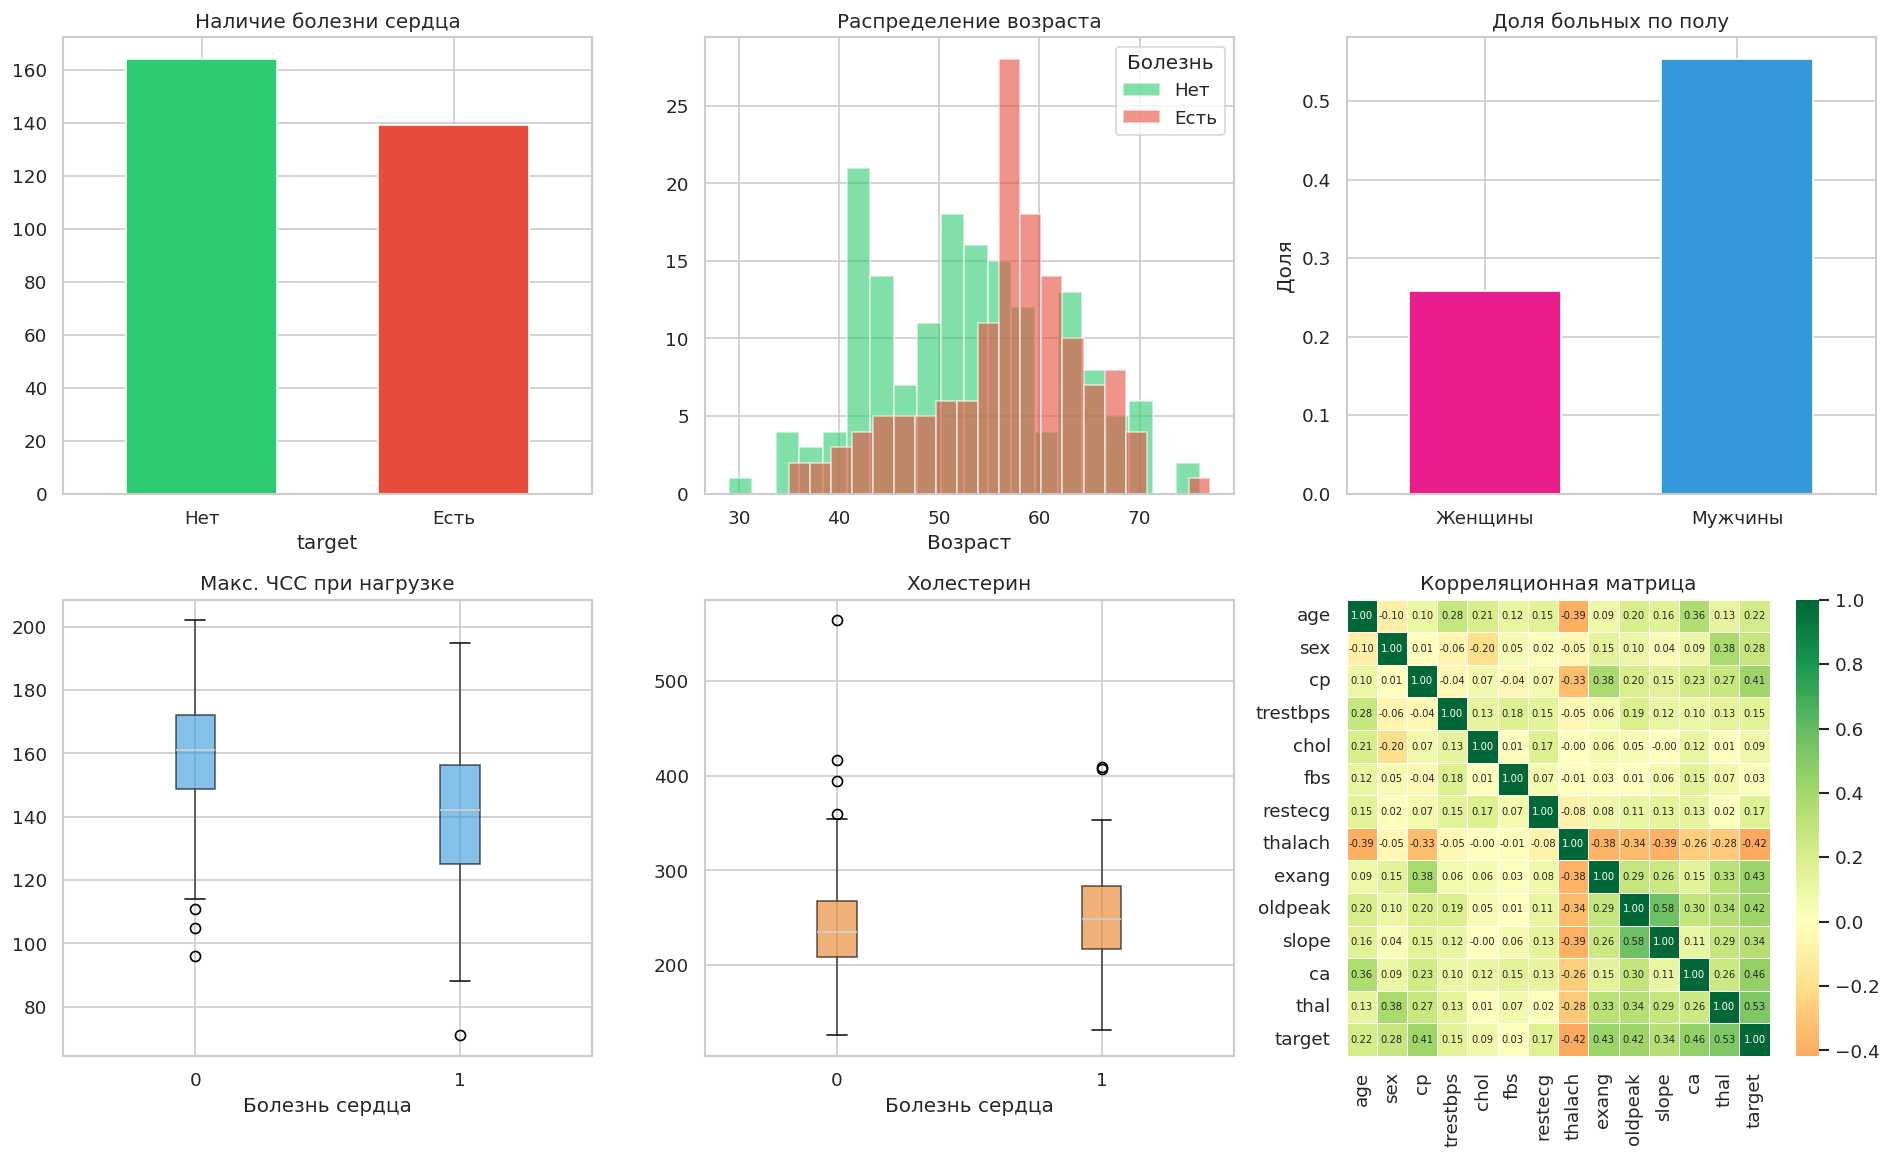

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA — Heart Disease Dataset', fontsize=16, fontweight='bold')

colors_target = ['#2ecc71', '#e74c3c']

df['target'].value_counts().rename({0: 'Нет', 1: 'Есть'}).plot(
    kind='bar', ax=axes[0,0], color=colors_target, edgecolor='white', width=0.6
)
axes[0,0].set_title('Наличие болезни сердца')
axes[0,0].set_xticklabels(['Нет', 'Есть'], rotation=0)

for val, color, label in [(0, '#2ecc71', 'Нет'), (1, '#e74c3c', 'Есть')]:
    df[df['target'] == val]['age'].hist(
        bins=20, ax=axes[0,1], alpha=0.6, color=color, label=label, edgecolor='white'
    )
axes[0,1].set_title('Распределение возраста')
axes[0,1].set_xlabel('Возраст')
axes[0,1].legend(title='Болезнь')

sex_target = df.groupby('sex')['target'].mean()
sex_target.index = ['Женщины', 'Мужчины']
sex_target.plot(
    kind='bar', ax=axes[0,2], color=['#e91e8c', '#3498db'], edgecolor='white', width=0.6
)
axes[0,2].set_title('Доля больных по полу')
axes[0,2].set_ylabel('Доля')
axes[0,2].tick_params(axis='x', rotation=0)

df.boxplot(column='thalach', by='target', ax=axes[1,0],
           patch_artist=True,
           boxprops=dict(facecolor='#3498db', alpha=0.6))
axes[1,0].set_title('Макс. ЧСС при нагрузке')
axes[1,0].set_xlabel('Болезнь сердца')
plt.sca(axes[1,0])
plt.title('Макс. ЧСС при нагрузке')

df.boxplot(column='chol', by='target', ax=axes[1,1],
           patch_artist=True,
           boxprops=dict(facecolor='#e67e22', alpha=0.6))
axes[1,1].set_title('Холестерин')
axes[1,1].set_xlabel('Болезнь сердца')
plt.sca(axes[1,1])
plt.title('Холестерин')

corr = df.corr()
sns.heatmap(
    corr, annot=True, fmt='.2f', cmap='RdYlGn',
    ax=axes[1,2], linewidths=0.5, center=0,
    annot_kws={'size': 6}
)
axes[1,2].set_title('Корреляционная матрица')

plt.suptitle('')
plt.tight_layout()
plt.show()

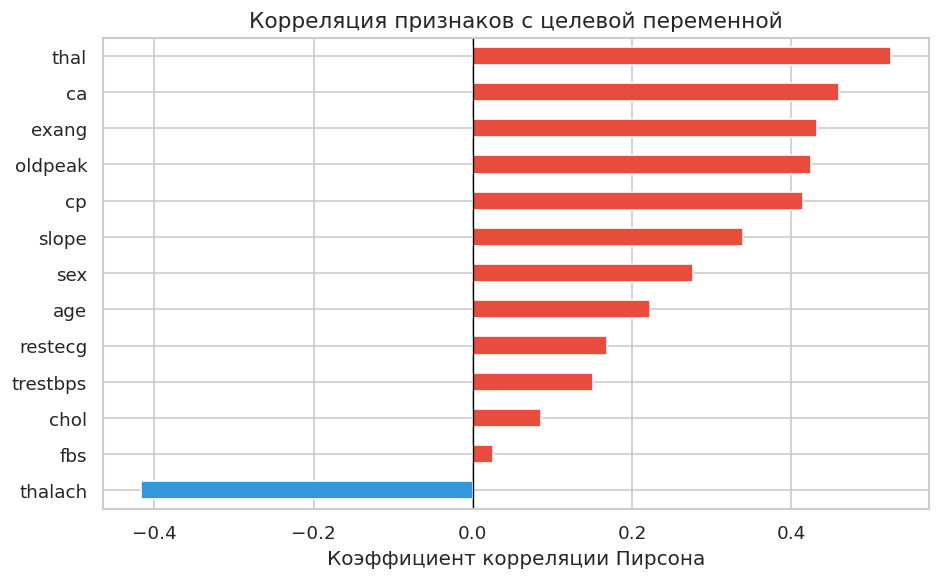

In [8]:
corr_target = df.corr()['target'].drop('target').sort_values()

plt.figure(figsize=(8, 5))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr_target]
corr_target.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Корреляция признаков с целевой переменной', fontsize=13)
plt.xlabel('Коэффициент корреляции Пирсона')
plt.tight_layout()
plt.show()

## 4. Предобработка данных
Заполняем пропуски медианой, категориальные признаки (для CatBoost) это cat_features_names

In [32]:
df = df.copy()

cat_features_names = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
cat_cols = [col for col in cat_features_names if col in df.columns]
num_cols = [col for col in df.columns if col not in cat_cols + ['target']]

df[num_cols] = df[num_cols].apply(pd.to_numeric, errors='coerce')
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].replace(['nan', 'None', 'NaN'], np.nan)
    df[col] = df[col].fillna('missing').astype(str)

X = df.drop('target', axis=1)
y = df['target']

cat_feature_indices = tuple(X.columns.get_loc(c) for c in cat_cols)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape[0]} | Test: {X_test.shape[0]}')
print(f'Доля класса 1 в train: {y_train.mean():.2%}')
print(f'Доля класса 1 в test:  {y_test.mean():.2%}')

Train: 242 | Test: 61
Доля класса 1 в train: 45.87%
Доля класса 1 в test:  45.90%


## 5. Обучение моделей и кросс-валидация

In [33]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, max_depth=8, random_state=42, n_jobs=-1
    ),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=9))
    ]),
}

cat_feature_indices = tuple(cat_feature_indices)

catboost_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    eval_metric='AUC',
    cat_features=cat_feature_indices,
    random_seed=42,
    verbose=0
)

In [34]:
results = {}

for name, model in models.items():
    t0 = time.time()
    cv_scores = cross_val_score(model, X_train, y_train, cv=cv,
                                 scoring='roc_auc', n_jobs=-1)
    model.fit(X_train, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'cv_roc_auc_mean': cv_scores.mean(),
        'cv_roc_auc_std':  cv_scores.std(),
        'test_accuracy':   accuracy_score(y_test, y_pred),
        'test_roc_auc':    roc_auc_score(y_test, y_prob),
        'test_f1':         f1_score(y_test, y_pred),
        'train_time_s':    round(train_time, 2),
        'model':           model,
        'y_prob':          y_prob,
    }
    print(f'{name:<25} CV ROC-AUC: {cv_scores.mean():.4f}')

t0 = time.time()
cv_scores_cb = cross_val_score(catboost_model, X_train, y_train, cv=cv,
                                scoring='roc_auc', n_jobs=1)
catboost_model.fit(X_train, y_train)
train_time = time.time() - t0

y_pred_cb = catboost_model.predict(X_test)
y_prob_cb = catboost_model.predict_proba(X_test)[:, 1]

results['CatBoost'] = {
    'cv_roc_auc_mean': cv_scores_cb.mean(),
    'cv_roc_auc_std':  cv_scores_cb.std(),
    'test_accuracy':   accuracy_score(y_test, y_pred_cb),
    'test_roc_auc':    roc_auc_score(y_test, y_prob_cb),
    'test_f1':         f1_score(y_test, y_pred_cb),
    'train_time_s':    round(train_time, 2),
    'model':           catboost_model,
    'y_prob':          y_prob_cb,
}
print(f'{"CatBoost":<25} CV ROC-AUC: {cv_scores_cb.mean():.4f}')

Logistic Regression       CV ROC-AUC: 0.8960
Random Forest             CV ROC-AUC: 0.8836
KNN                       CV ROC-AUC: 0.8908
CatBoost                  CV ROC-AUC: 0.8733


## 6. Сводная таблица результатов

In [35]:
summary = pd.DataFrame([
    {
        'Модель': name,
        'CV ROC-AUC': f"{v['cv_roc_auc_mean']:.4f}",
        'Test Accuracy': f"{v['test_accuracy']:.4f}",
        'Test ROC-AUC': f"{v['test_roc_auc']:.4f}",
        'Test F1': f"{v['test_f1']:.4f}",
        'Время обучения (с)': v['train_time_s'],
    }
    for name, v in results.items()
])

summary = summary.sort_values('Test ROC-AUC', ascending=False).reset_index(drop=True)
summary.style.highlight_max(
    subset=['Test ROC-AUC', 'Test Accuracy', 'Test F1'],
    color='#c8f5c2'
).set_caption('Сравнение моделей на Heart Disease')

,Модель,CV ROC-AUC,Test Accuracy,Test ROC-AUC,Test F1,Время обучения (с)
0,CatBoost,0.8733,0.8852,0.9643,0.8852,13.190000
1,KNN,0.8908,0.9016,0.9583,0.9032,0.070000
2,Random Forest,0.8836,0.8852,0.9556,0.8814,3.430000
3,Logistic Regression,0.8960,0.8689,0.9513,0.8667,2.570000


## 7. Визуализация результатов

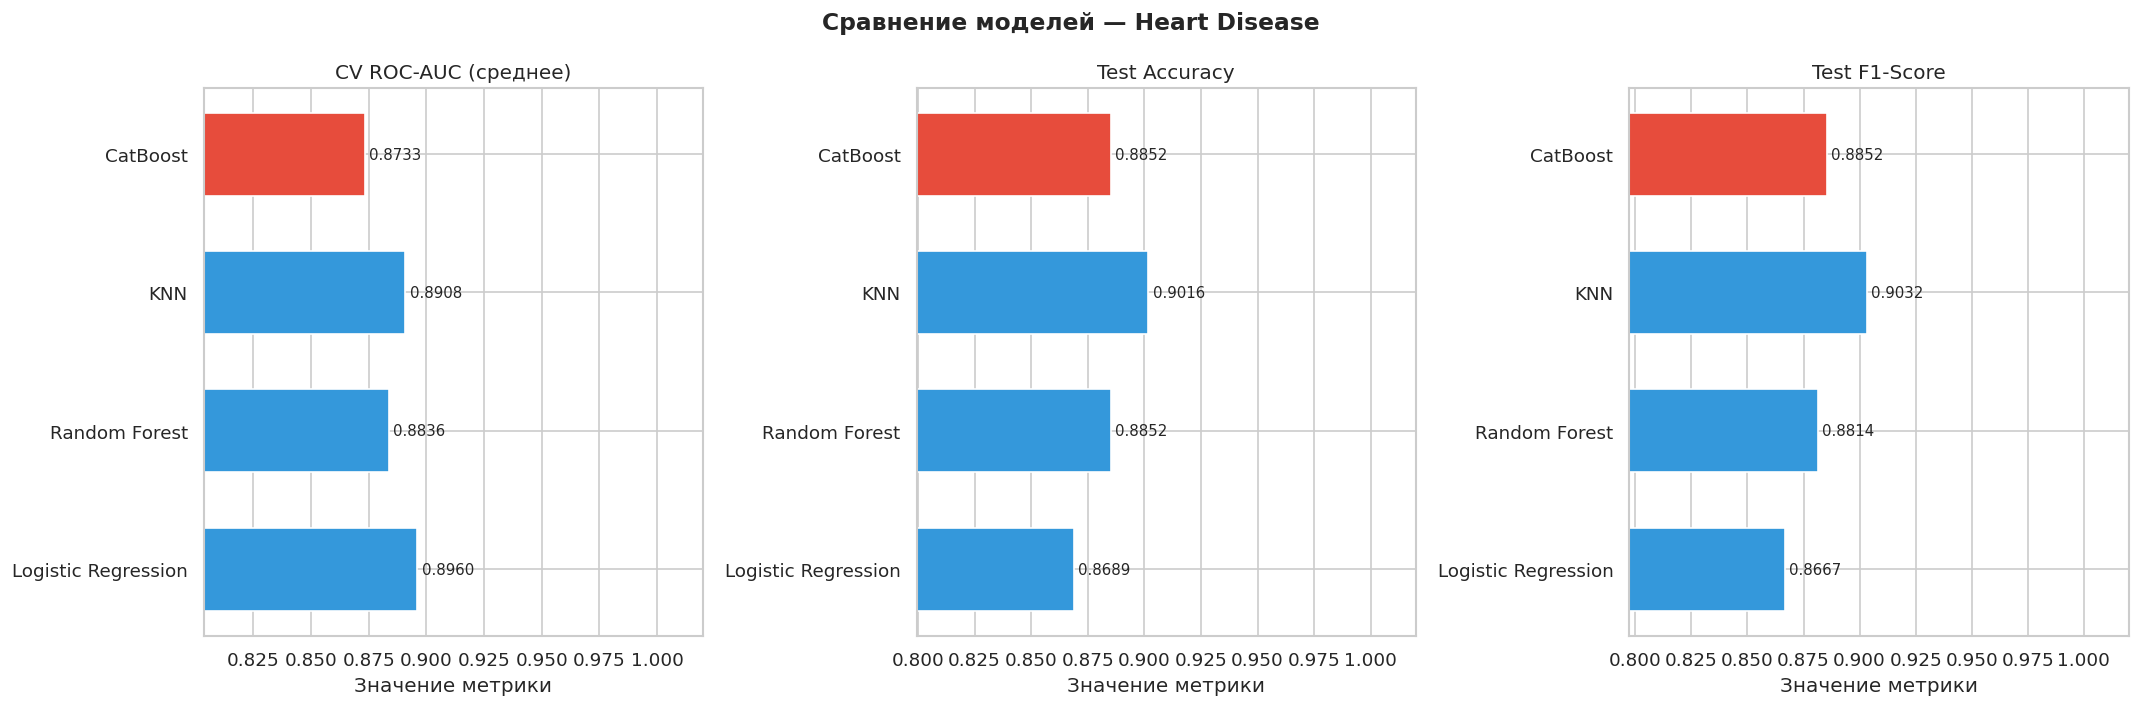

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Сравнение моделей — Heart Disease', fontsize=14, fontweight='bold')

model_names = list(results.keys())
palette = ['#e74c3c' if 'CatBoost' in n else '#3498db' for n in model_names]

metrics = [
    ('cv_roc_auc_mean', 'CV ROC-AUC (среднее)'),
    ('test_accuracy',   'Test Accuracy'),
    ('test_f1',         'Test F1-Score'),
]

for ax, (metric, title) in zip(axes, metrics):
    values = [results[n][metric] for n in model_names]
    bars = ax.barh(model_names, values, color=palette, edgecolor='white', height=0.6)
    ax.set_xlim(min(values) * 0.92, 1.02)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Значение метрики')
    for bar, val in zip(bars, values):
        ax.text(
            bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9
        )

plt.tight_layout()
plt.show()

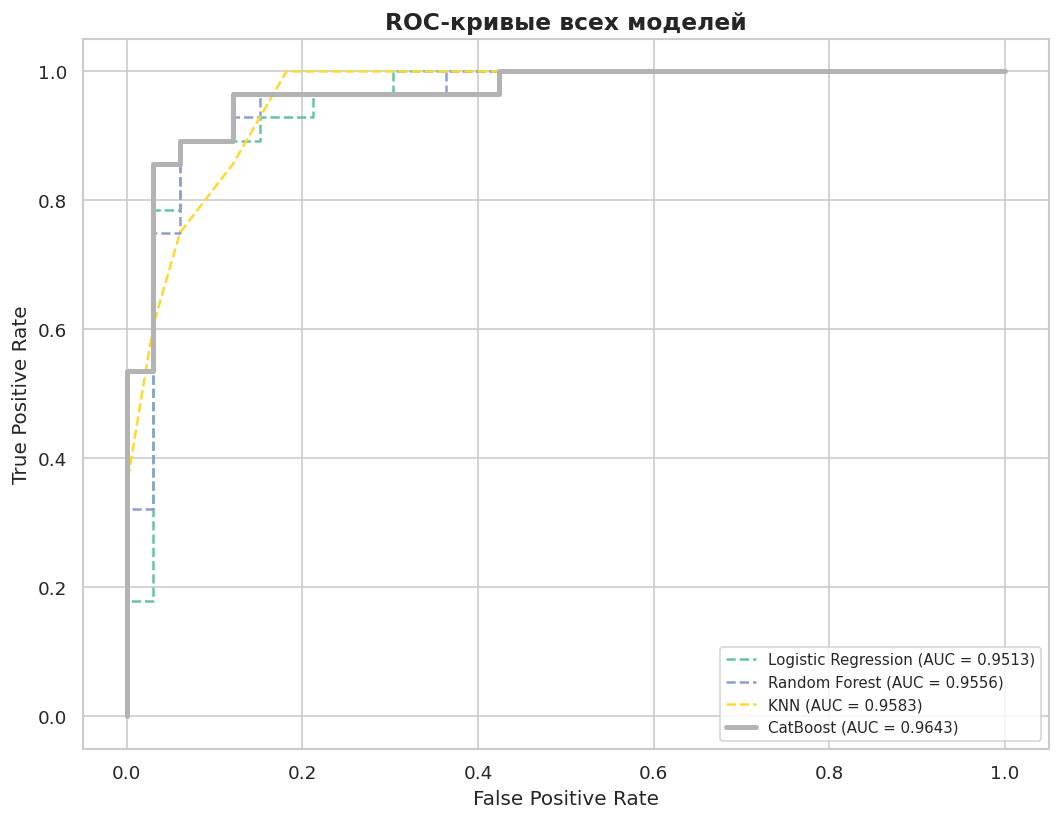

In [37]:
plt.figure(figsize=(9, 7))

colors_roc = plt.cm.Set2(np.linspace(0, 1, len(results)))

for (name, v), color in zip(results.items(), colors_roc):
    fpr, tpr, _ = roc_curve(y_test, v['y_prob'])
    lw = 3 if 'CatBoost' in name else 1.5
    ls = '-' if 'CatBoost' in name else '--'
    plt.plot(fpr, tpr, lw=lw, linestyle=ls, color=color,
             label=f"{name} (AUC = {v['test_roc_auc']:.4f})")

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC-кривые всех моделей', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

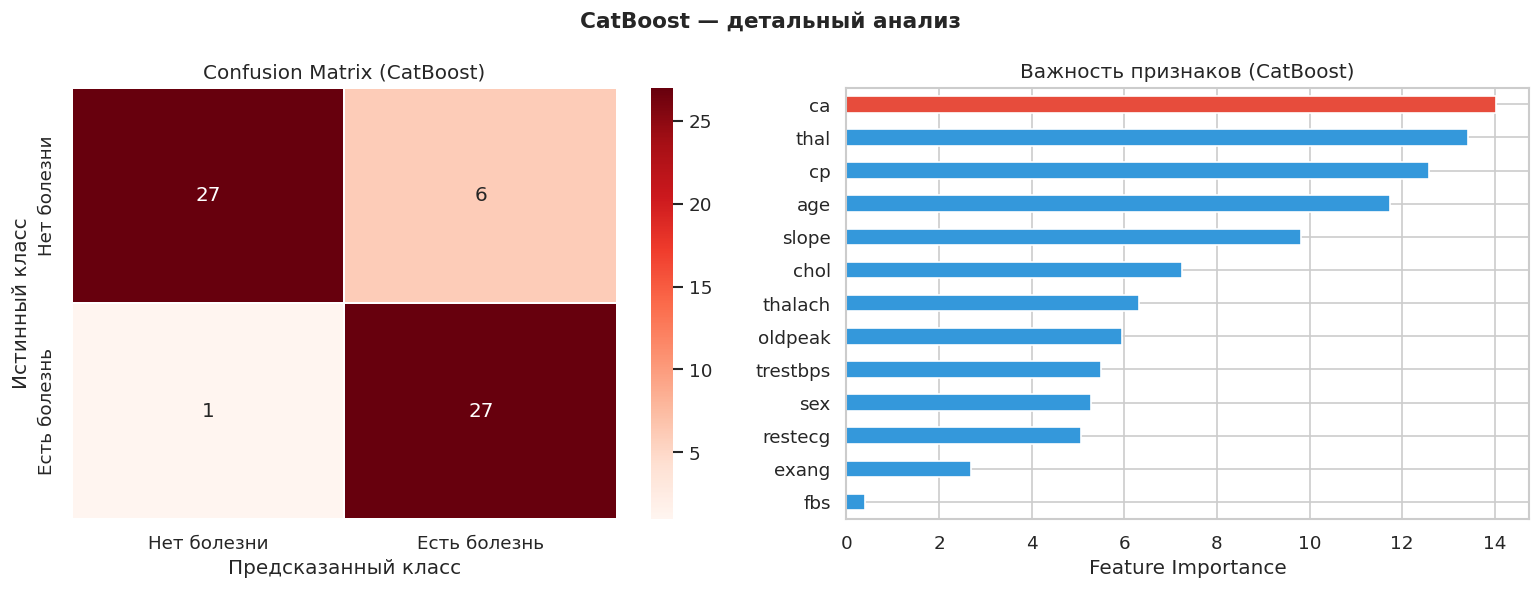

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('CatBoost — детальный анализ', fontsize=13, fontweight='bold')

cm = confusion_matrix(y_test, catboost_model.predict(X_test))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Reds',
    ax=axes[0], linewidths=1,
    xticklabels=['Нет болезни', 'Есть болезнь'],
    yticklabels=['Нет болезни', 'Есть болезнь']
)
axes[0].set_title('Confusion Matrix (CatBoost)')
axes[0].set_ylabel('Истинный класс')
axes[0].set_xlabel('Предсказанный класс')

feat_imp = pd.Series(
    catboost_model.get_feature_importance(),
    index=X.columns
).sort_values(ascending=True)

colors_fi = ['#e74c3c' if v == feat_imp.max() else '#3498db' for v in feat_imp.values]
feat_imp.plot(kind='barh', ax=axes[1], color=colors_fi, edgecolor='white')
axes[1].set_title('Важность признаков (CatBoost)')
axes[1].set_xlabel('Feature Importance')

plt.tight_layout()
plt.show()

In [40]:
print('Classification Report — CatBoost')
print(classification_report(
    y_test, catboost_model.predict(X_test),
    target_names=['Нет болезни', 'Есть болезнь']
))

Classification Report — CatBoost
              precision    recall  f1-score   support

 Нет болезни       0.96      0.82      0.89        33
Есть болезнь       0.82      0.96      0.89        28

    accuracy                           0.89        61
   macro avg       0.89      0.89      0.89        61
weighted avg       0.90      0.89      0.89        61



## 8. Кривые обучения CatBoost

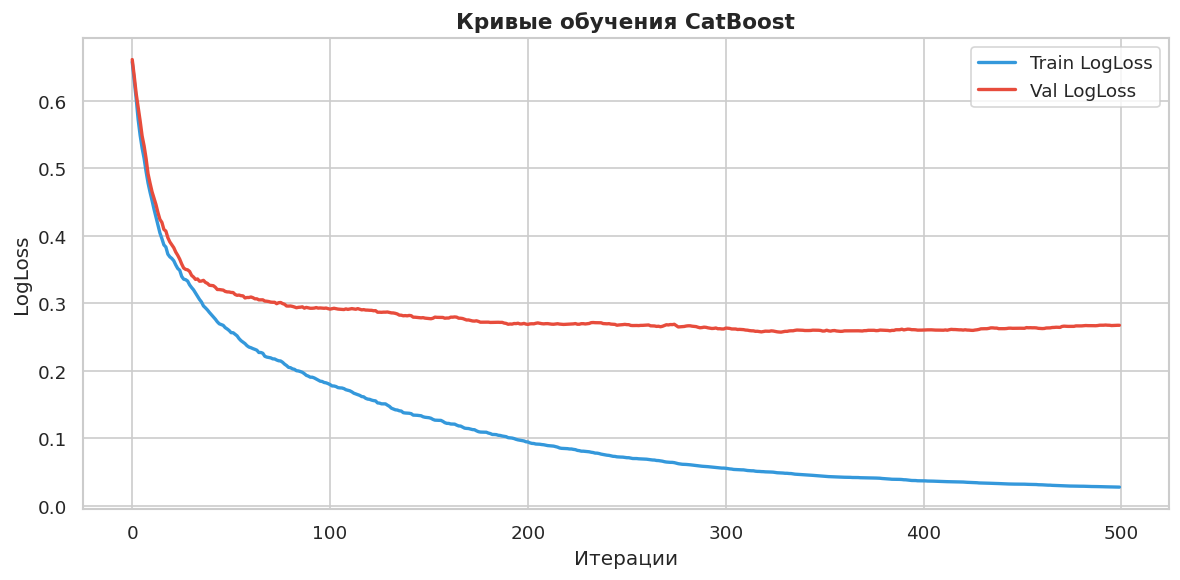

In [41]:
cb_eval = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    loss_function='Logloss',
    cat_features=cat_feature_indices,
    random_seed=42,
    verbose=0
)

cb_eval.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    plot=False
)

train_logloss = cb_eval.evals_result_['learn']['Logloss']
val_logloss   = cb_eval.evals_result_['validation']['Logloss']

plt.figure(figsize=(10, 5))
plt.plot(train_logloss, label='Train LogLoss', color='#3498db', lw=2)
plt.plot(val_logloss,   label='Val LogLoss',   color='#e74c3c', lw=2)
plt.xlabel('Итерации')
plt.ylabel('LogLoss')
plt.title('Кривые обучения CatBoost', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

## 9. Итоги и выводы

In [44]:
best_model = max(results, key=lambda n: results[n]['test_roc_auc'])
best_auc = results[best_model]['test_roc_auc']

print('=' * 50)
print('  ИТОГОВЫЙ ОТЧЁТ — Heart Disease Classification')
print('=' * 50)
print(f'  Лучшая модель по Test ROC-AUC: {best_model}')
print(f'  Test ROC-AUC:  {best_auc:.4f}')
print(f'  Test Accuracy: {results[best_model]["test_accuracy"]:.4f}')
print(f'  Test F1:       {results[best_model]["test_f1"]:.4f}')
print('=' * 50)
print()
print('Ранжирование по Test ROC-AUC:')
for i, (name, v) in enumerate(
    sorted(results.items(), key=lambda x: -x[1]['test_roc_auc']), 1
):
    print(f'  {i}. {name:<25} ROC-AUC: {v["test_roc_auc"]:.4f}')
print()
print('Ключевые наблюдения:')
print('  • CatBoost нативно обрабатывает категориальные признаки')
print('  • Топ-признаки по важности: cp (тип боли), thalach, ca, oldpeak')
print('  • Градиентный бустинг (CatBoost) превосходит')
print('    линейные методы на этом датасете')

  ИТОГОВЫЙ ОТЧЁТ — Heart Disease Classification
  Лучшая модель по Test ROC-AUC: CatBoost
  Test ROC-AUC:  0.9643
  Test Accuracy: 0.8852
  Test F1:       0.8852

Ранжирование по Test ROC-AUC:
  1. CatBoost                  ROC-AUC: 0.9643
  2. KNN                       ROC-AUC: 0.9583
  3. Random Forest             ROC-AUC: 0.9556
  4. Logistic Regression       ROC-AUC: 0.9513

Ключевые наблюдения:
  • CatBoost нативно обрабатывает категориальные признаки
  • Топ-признаки по важности: cp (тип боли), thalach, ca, oldpeak
  • Градиентный бустинг (CatBoost) превосходит
    линейные методы на этом датасете
